In [1]:
import numpy as np
import pandas as pd
import xarray as xr
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
from pathlib import Path
%run '../helper_funcs.ipynb'

In [12]:
def ozone_concentration_ts(hist, aunz, bona, tena):
    # Condense ozone data into 2D 
    ozone_to_plot = []
    times = []
    for ds in [hist, aunz, bona, tena]:
        ds_prep = ds.drop_vars('ilev')
        ds_sfc = ds_prep.sel(lev=max(ds.lev.values))
        ds_flat = ds_sfc.mean(dim=['lat','lon'])
        ozone = ds_flat.O3.values
        ozone_to_plot.append(ozone)
        times.append(ds_flat.time)

    labels = ['Global Run', 'AUNZ Mask', 'BONA Mask', 'TENA Mask']
    colors = ['maroon', 'orangered', 'orange', 'gold']
    
    fig = plt.figure(figsize=(10,8))
    ax = plt.axes()
    
    # Add data to figure window
    for i in range(len(ozone_to_plot)):
        plt.plot(times[i], ozone_to_plot[i], label=labels[i], c=colors[i])
    plt.legend()
    plt.xlabel('Time', fontsize=14)
    plt.ylabel('molecules/cm²/s', fontsize=14)
    plt.title('Surface Ozone Concentration by Simulation, 2015 - 2020')

In [5]:
hist_run = create_big_ds('/glade/work/ekeefe/research_code/emmons_output/emmons_spinup_corr/jan_june')
aunz_run = create_big_ds('/glade/work/ekeefe/research_code/model_output/mask_aunz_output')
bona_run = create_big_ds('/glade/work/ekeefe/research_code/model_output/mask_bona_output')
tena_run = create_big_ds('/glade/work/ekeefe/research_code/model_output/mask_tena_output')

/glade/derecho/scratch/ekeefe/tmp/ipykernel_38278/3957096376.py:22: FutureWarning: In a future version of xarray the default value for data_vars will change from data_vars='all' to data_vars=None. This is likely to lead to different results when multiple datasets have matching variables with overlapping values. To opt in to new defaults and get rid of these warnings now use `set_options(use_new_combine_kwarg_defaults=True) or set data_vars explicitly.
  big_ds = xr.open_mfdataset(files, compat='override', coords='minimal', engine='netcdf4')
/glade/derecho/scratch/ekeefe/tmp/ipykernel_38278/3957096376.py:22: FutureWarning: In a future version of xarray the default value for data_vars will change from data_vars='all' to data_vars=None. This is likely to lead to different results when multiple datasets have matching variables with overlapping values. To opt in to new defaults and get rid of these warnings now use `set_options(use_new_combine_kwarg_defaults=True) or set data_vars explicitl

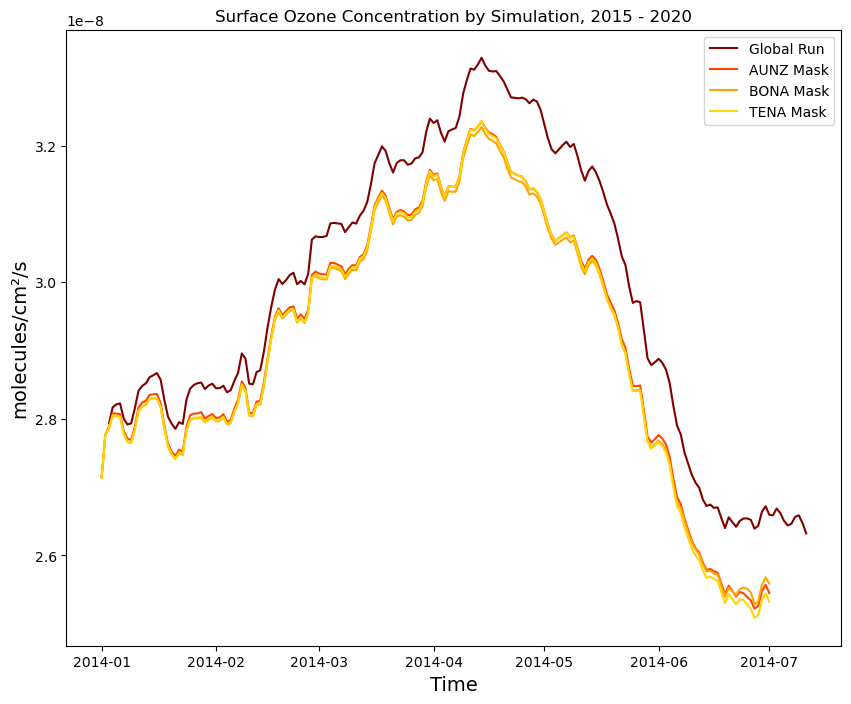

In [13]:
ozone_concentration_ts(hist_run, aunz_run, bona_run, tena_run)

In [16]:
bona_run.PM25

<xarray.DataArray 'PM25' (time: 182, lev: 32, lat: 192, lon: 288)> Size: 1GB
dask.array<concatenate, shape=(182, 32, 192, 288), dtype=float32, chunksize=(10, 32, 192, 288), chunktype=numpy.ndarray>
Coordinates:
  * time     (time) datetime64[ns] 1kB 2014-01-01 2014-01-02 ... 2014-07-01
  * lev      (lev) float64 256B 3.643 7.595 14.36 24.61 ... 957.5 976.3 992.6
  * lat      (lat) float64 2kB -90.0 -89.06 -88.12 -87.17 ... 88.12 89.06 90.0
  * lon      (lon) float64 2kB 0.0 1.25 2.5 3.75 5.0 ... 355.0 356.2 357.5 358.8
Attributes:
    mdims:         1
    units:         kg/m3
    long_name:     PM2.5 concentration
    cell_methods:  time: mean

In [17]:
def pm_concentration_ts(hist, aunz, bona, tena):
    pm_to_plot = []
    times = []
    for ds in [hist, aunz, bona, tena]:
        ds_prep = ds.drop_vars('ilev')
        ds_sfc = ds_prep.sel(lev=max(ds.lev.values))
        ds_flat = ds_sfc.mean(dim=['lat','lon'])
        pm = ds_flat.PM25.values
        pm_to_plot.append(pm)
        times.append(ds_flat.time)

    labels = ['Global Run', 'AUNZ Mask', 'BONA Mask', 'TENA Mask']
    colors = ['maroon', 'orangered', 'orange', 'gold']
    
    fig = plt.figure(figsize=(10,8))
    ax = plt.axes()
    
    # Add data to figure window
    for i in range(len(pm_to_plot)):
        plt.plot(times[i], pm_to_plot[i], label=labels[i], c=colors[i])
    plt.legend()
    plt.xlabel('Time', fontsize=14)
    plt.ylabel('kg/m³', fontsize=14)
    plt.title('Surface PM₂₅ Concentration by Simulation, 2015 - 2020')

In [18]:
pm_concentration_ts(hist_run, aunz_run, bona_run, tena_run)

AttributeError: 'Dataset' object has no attribute 'PM25'